# Прогноз отмены бронирования 

###  Описание исследования  
В рамках данного исследования анализируется проблема массовых отмен бронирований в сети отелей UrbanStay.  
Частые и поздние отмены приводят к финансовым потерям, снижению загрузки номерного фонда и ухудшению отношений с партнёрами.  
Текущее решение в виде овербукинга является рискованным и неуправляемым.  
Исследование направлено на разработку модели машинного обучения, способной прогнозировать вероятность отмены бронирования и тем самым повысить управляемость процессов и экономическую эффективность бизнеса.  

###  Цель исследования  
Разработать и внедрить модель машинного обучения, которая прогнозирует вероятность отмены бронирования и позволяет:  
снизить долю отмен до 10%  
повысить загрузку отелей  
увеличить доход за счёт более эффективного управления бронированиями.  

###  Задачи исследования  
Загрузить данные из базы данных и подготовить их к анализу.  
Провести исследовательский анализ данных (EDA), выявить пропуски, аномалии и особенности распределений.  
Объединить данные о бронированиях и отзывах клиентов.  
Создать новые признаки (feature engineering), включая признаки на основе текстов отзывов.  
Обучить и сравнить несколько моделей машинного обучения.  
Подобрать гиперпараметры моделей с использованием оптимизации (например, Optuna).  
Откалибровать лучшую модель и подобрать оптимальный порог классификации.  
Оценить качество модели с точки зрения бизнес-метрик.  
Рассчитать экономическую эффективность внедрения модели (Incremental Revenue).  
Проанализировать важность признаков и интерпретировать результаты.  

###  Описание исходных данных  
В исследовании используются два источника данных:  
Таблица hotel_bookings — содержит информацию о бронированиях (35 341 запись).  
Каждая строка представляет отдельное бронирование и включает характеристики клиента, параметры проживания и статус брони.  
Целевая переменная — booking_status (отмена или отсутствие отмены).  

Таблица hotel_reviews — содержит отзывы клиентов (25 177 записей).  
Включает текстовые комментарии и оценки проживания, связанные с конкретными бронированиями.  

Данные объединяются по идентификатору бронирования и временной логике:  
для каждой брони используется ближайший предыдущий отзыв клиента.  

###  Постановка задачи машинного обучения и метрики  
Задача машинного обучения — бинарная классификация:  
предсказать вероятность отмены бронирования (отказ или отсутствие отказа).  

Модель должна не только показывать высокое качество предсказаний, но и оптимизировать бизнес-результаты.  

Основная метрика — Incremental Revenue (IR), отражающая экономический эффект от внедрения модели.  
Дополнительно анализируются:  
доля отмен бронирований до и после внедрения модели  
загрузка отелей  
матрица ошибок (TP, FP, TN, FN) для оценки качества классификации.  

## Загрузка необходимых библиотек

In [1]:
!pip install -q optuna shap

In [2]:
# базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# работа с бд (sql)
from sqlalchemy import create_engine

# предобработка
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler,  OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone


# модели
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.isotonic import IsotonicRegression
from scipy import sparse


# метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, brier_score_loss, log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# калибровка
from sklearn.calibration import CalibratedClassifierCV

# оптимизация 
import optuna

# nlp (для отзывов)
from sklearn.feature_extraction.text import TfidfVectorizer

import shap

# предобработка текста 
import re
import nltk
from nltk.corpus import stopwords
from pymorphy2 import MorphAnalyzer

## Этап 1: подготовка данных

### Загрузка данных

In [ ]:
db_config = {'user': '', 
             'pwd': '', 
             'host': '',
             'port': , 
             'db': '' 
             }

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
SELECT *
FROM hotel_bookings
'''

In [6]:
df_bookings = pd.read_sql_query(query, con=engine)

In [7]:
df_bookings.head()

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


In [8]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  object 
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  object 
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  object 
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  obj

In [9]:
query = '''
SELECT *
FROM hotel_reviews
'''

In [10]:
df_reviews = pd.read_sql_query(query, con=engine)

In [11]:
pd.set_option('display.max_colwidth', None)

In [12]:
df_reviews.head()

,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


In [13]:
df_reviews.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  object
 1   booking_id   25177 non-null  object
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  object
dtypes: int64(1), object(4)
memory usage: 983.6+ KB


- Данные успешно загружены  
- Поля соответствуют описанию
- Заметим сразу, что пропусков в данных нет 

### Исследовательский анализ данных и предобработка

#### Пропуски и дубликаты

In [14]:
df_bookings.isna().mean().sort_values(ascending=False)

booking_id                   0.0
booking_value                0.0
room_type                    0.0
parking_included             0.0
meal_plan                    0.0
weekend_nights               0.0
weekday_nights               0.0
days_until_checkin           0.0
booking_status               0.0
booking_date                 0.0
previous_no_shows            0.0
previous_cancellations       0.0
returning_customer           0.0
child_count                  0.0
adult_count                  0.0
sales_channel                0.0
customer_special_requests    0.0
dtype: float64

In [15]:
df_reviews.isna().mean().sort_values(ascending=False)

customer_id    0.0
booking_id     0.0
review_date    0.0
stay_rating    0.0
review_text    0.0
dtype: float64

пропусков в данных нет 

In [16]:
print(len(df_bookings))
df_bookings = df_bookings.drop_duplicates().copy()
len(df_bookings)

35341


30733

в бронированиях было почти 5 тысяч полных дубликатов

In [17]:
# айди должны быть уникальными 

df_bookings['booking_id'].duplicated().sum()

0

все записи имеют уникальный айди  

In [18]:
print(len(df_reviews))
df_reviews = df_reviews.drop_duplicates().copy()
len(df_reviews)

25177


25177

в отзывах дубликатов не было 

#### Распределение таргета 

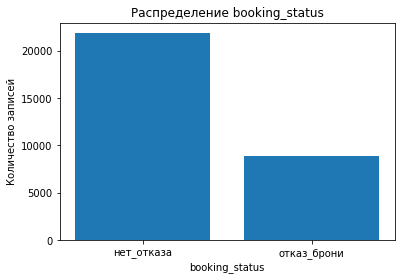

In [19]:
temp = df_bookings['booking_status'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(temp.index.astype(str), temp.values)
plt.xlabel('booking_status')
plt.ylabel('Количество записей')
plt.title('Распределение booking_status')
plt.show()

In [20]:
df_bookings['booking_status'].value_counts(normalize=True)

нет_отказа     0.712036
отказ_брони    0.287964
Name: booking_status, dtype: float64

как и было сказано в описании задачи, в данных есть дисбаланс. это стоит учитывать при построении моделей. 

#### Анализ таблицы с бронированиями  

In [21]:
sns.set_theme(style='darkgrid')

def plot_outliers(df, col, bins=50):
    """
    Строит boxplot и гистограмму для численного признака.
    """

    f, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)},
        figsize=(10, 6))

    sns.boxplot(
        x=df[col],
        orient='h',
        ax=ax_box)

    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=ax_hist)

    ax_box.set(xlabel='')
    ax_hist.set_xlabel(col)
    ax_hist.set_title(f'Распределение и boxplot признака {col}')

    plt.tight_layout()
    plt.show()

In [22]:
def plot_categorical(df, col):
    """
    Строит распределение категориального признака:
    - barplot (частоты)
    - таблицу долей (%)
    """
    

    counts = df[col].value_counts()
    
    # если категории можно отсортировать — сортируем
    try:
        counts = counts.sort_index()
    except:
        pass

    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values
    )
    
    plt.xlabel(col)
    plt.ylabel('Количество')
    plt.title(f'Распределение признака {col}')
    
    plt.tight_layout()
    plt.show()
    
    percent = (counts / len(df) * 100).round(2)
    
    percent_df = percent.to_frame(name='percent')
    
    print("\nДоли (%):")
    display(percent_df)

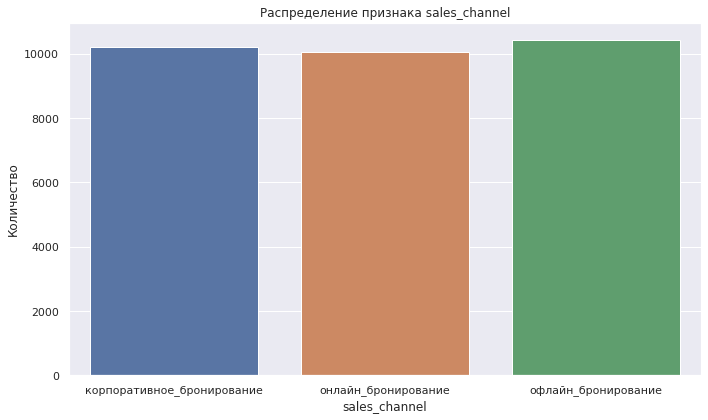


Доли (%):


,percent
корпоративное_бронирование,33.28
онлайн_бронирование,32.73
офлайн_бронирование,33.99


In [23]:
plot_categorical(df_bookings, 'sales_channel')

равномерное распределение по каждой категории 

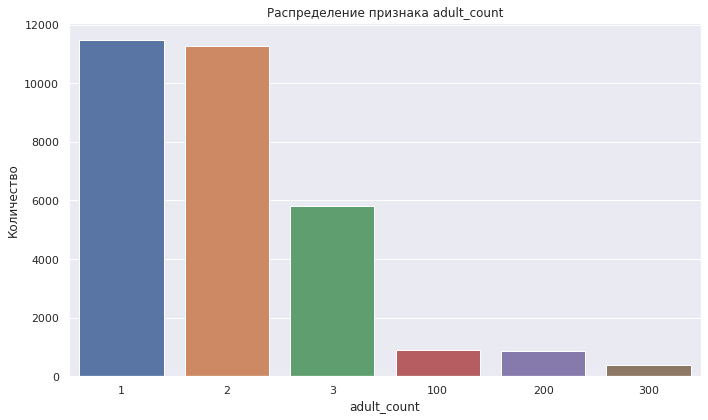


Доли (%):


,percent
1,37.39
2,36.68
3,18.94
100,2.88
200,2.84
300,1.29


In [24]:
plot_categorical(df_bookings, 'adult_count')

в данных есть корпоративные бронирования на 100-300 человек. таких бронирований мало: в сумме около 7%. Чаще всего бронируют номер на 1 или 2 человека. 

In [25]:
df_bookings.loc[df_bookings['adult_count'] > 50, 'adult_count'] /= 100

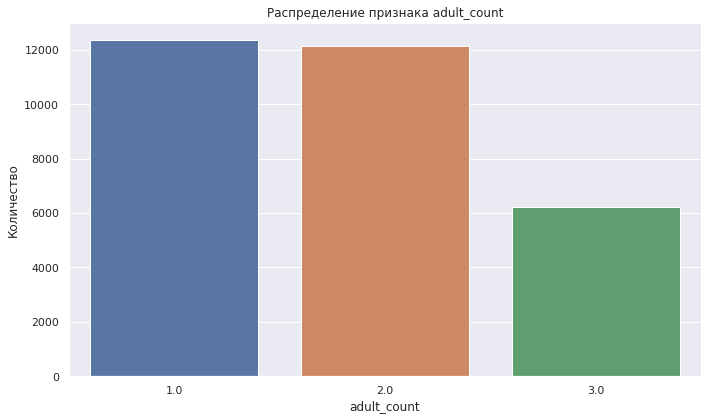


Доли (%):


,percent
1.0,40.26
2.0,39.51
3.0,20.22


In [26]:
plot_categorical(df_bookings, 'adult_count')

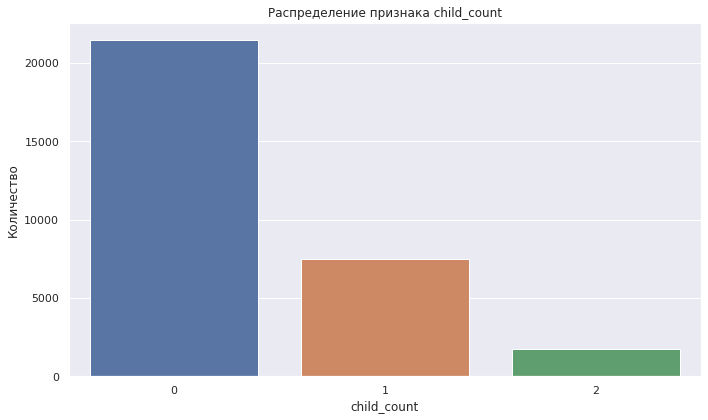


Доли (%):


,percent
0,69.94
1,24.44
2,5.61


In [27]:
plot_categorical(df_bookings, 'child_count')

чаще всего 0 детей. 2 ребенка только в 5 процентах случаев

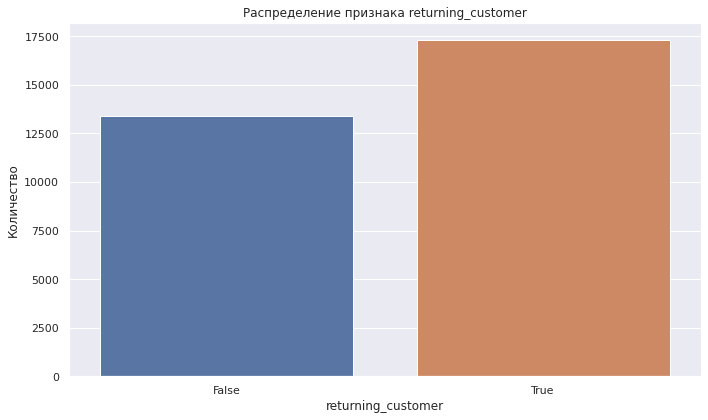


Доли (%):


,percent
False,43.63
True,56.37


In [28]:
plot_categorical(df_bookings, 'returning_customer')

чуть менее половины брони - новые клиенты 

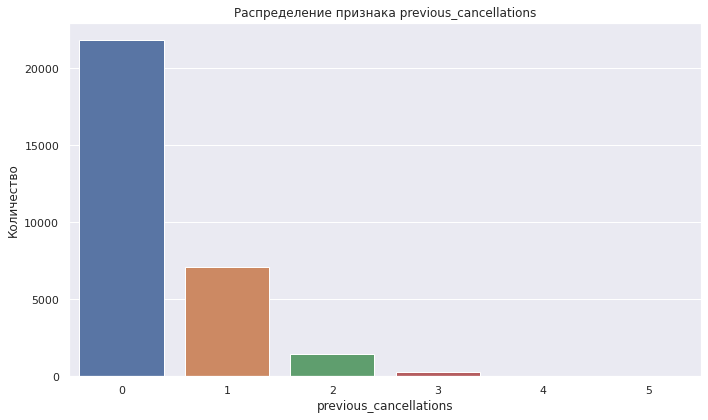


Доли (%):


,percent
0,71.17
1,23.16
2,4.62
3,0.87
4,0.16
5,0.01


In [29]:
plot_categorical(df_bookings, 'previous_cancellations')

у 71% посетителей отмены ранее не было. у 23% 1 отмена. более 1 отмены у 5 процентов. 

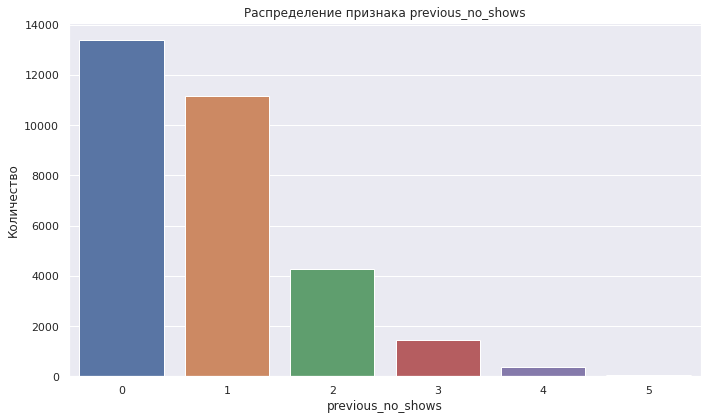


Доли (%):


,percent
0,43.63
1,36.38
2,13.95
3,4.67
4,1.26
5,0.12


In [30]:
plot_categorical(df_bookings, 'previous_no_shows')

0 - это новые клиенты. доля нулей совпадает с долей новых клиентов. 36% клиентов заселялось.  

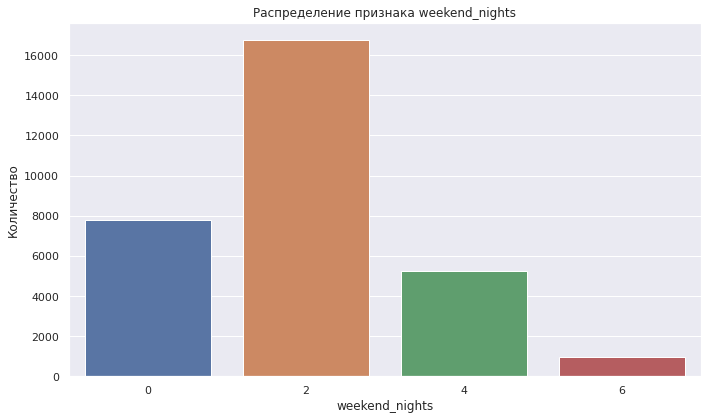


Доли (%):


,percent
0,25.35
2,54.60
4,16.99
6,3.05


In [31]:
plot_categorical(df_bookings, 'weekend_nights')

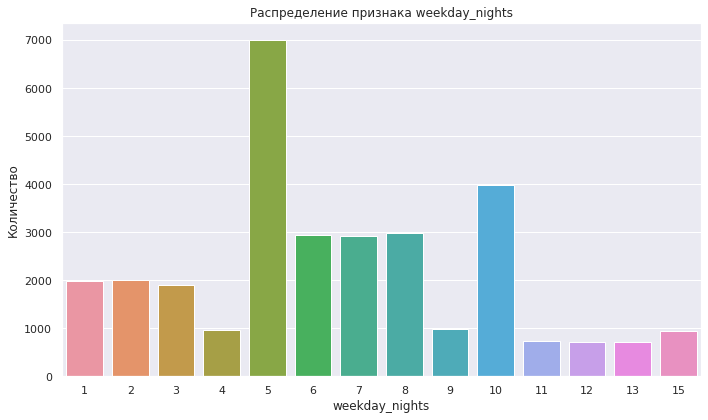


Доли (%):


,percent
1,6.43
2,6.49
3,6.21
4,3.14
5,22.81
6,9.57
7,9.48
8,9.74
9,3.19
10,12.92


In [32]:
plot_categorical(df_bookings, 'weekday_nights')

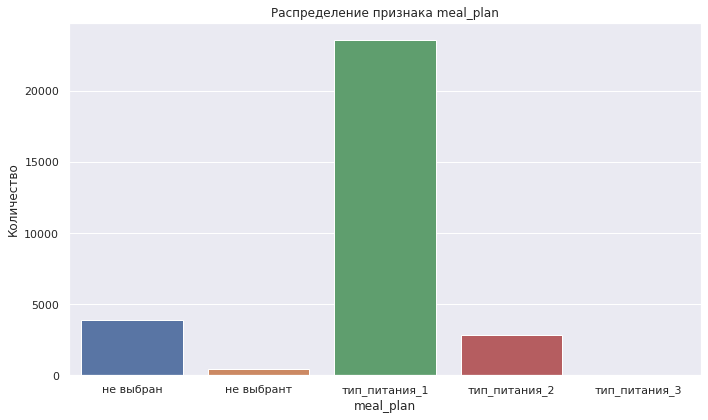


Доли (%):


,percent
не выбран,12.59
не выбрант,1.40
тип_питания_1,76.80
тип_питания_2,9.20
тип_питания_3,0.02


In [33]:
plot_categorical(df_bookings, 'meal_plan')

в данных есть опечатка: категория не выбрант была неверно записана. исправим это. 

In [34]:
df_bookings['meal_plan'] = df_bookings['meal_plan'].replace('не выбрант', 'не выбран')

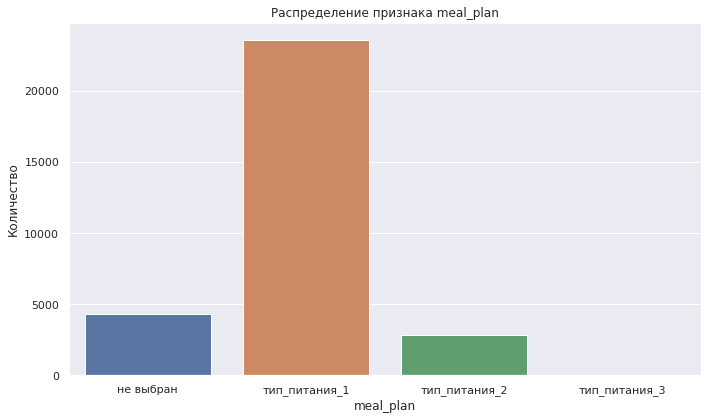


Доли (%):


,percent
не выбран,13.98
тип_питания_1,76.80
тип_питания_2,9.20
тип_питания_3,0.02


In [35]:
plot_categorical(df_bookings, 'meal_plan')

устранили ошибку  
большая часть людей выбирает тип питания 1 (76%) 

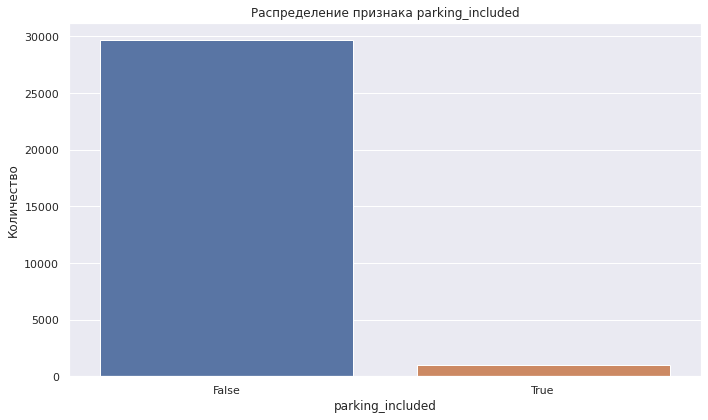


Доли (%):


,percent
False,96.73
True,3.27


In [36]:
plot_categorical(df_bookings, 'parking_included')

In [37]:
df_bookings.groupby('parking_included')['booking_status'].value_counts(normalize=True)

parking_included  booking_status
False             нет_отказа        0.712830
                  отказ_брони       0.287170
True              нет_отказа        0.688557
                  отказ_брони       0.311443
Name: booking_status, dtype: float64

почти у всех значение 0. но при этом доля отказов все-таки меняеся. оставим признак  

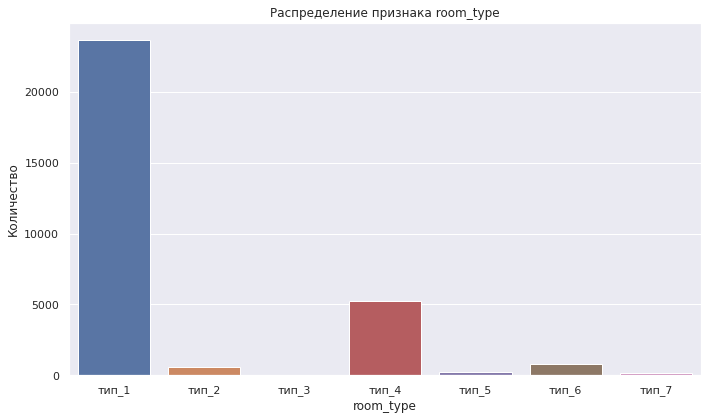


Доли (%):


,percent
тип_1,77.07
тип_2,1.88
тип_3,0.03
тип_4,17.06
тип_5,0.79
тип_6,2.71
тип_7,0.47


In [38]:
plot_categorical(df_bookings, 'room_type')

почти все тип_1 или тип_2

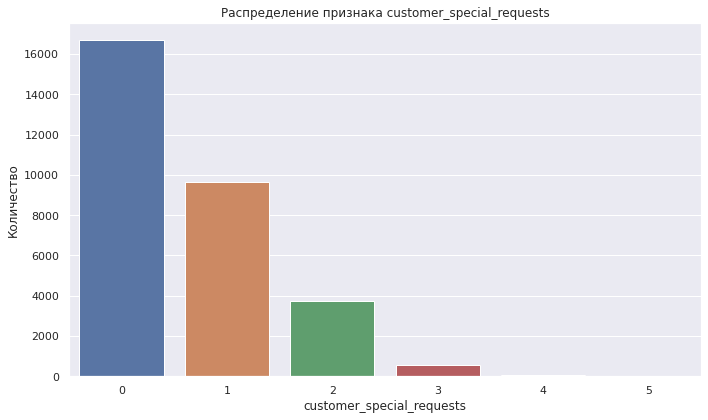


Доли (%):


,percent
0,54.39
1,31.42
2,12.18
3,1.78
4,0.21
5,0.02


In [39]:
plot_categorical(df_bookings, 'customer_special_requests')

чуть менее половины гостей имеют специальные запросы 

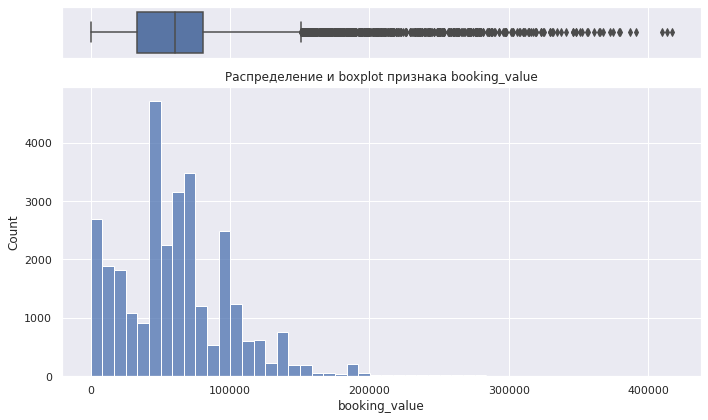

In [40]:
plot_outliers(df_bookings, 'booking_value')

Длинный правый хвост. Аномально высокие значения - это корпоративные бронирования, то есть реальный данные. Тк модели деревянные, не будем ничего делать 

In [41]:
print("До:", len(df_bookings))

df_bookings = df_bookings[df_bookings['booking_value'] != 0]

print("После:", len(df_bookings))

До: 30733
После: 29504


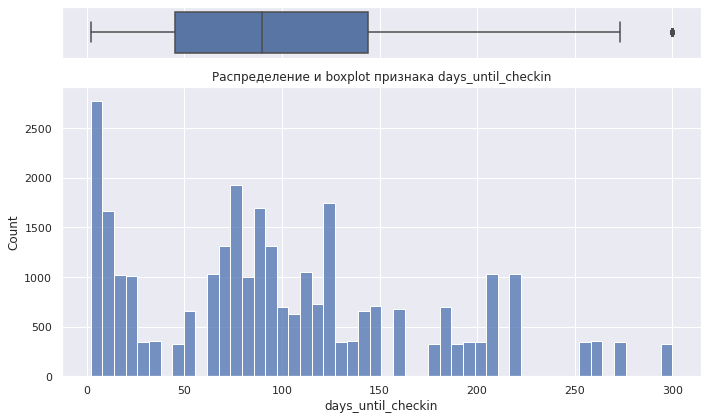

In [42]:
plot_outliers(df_bookings, 'days_until_checkin')

аномалий нет. бронь за 10 месяцев (особенное если это корпоративное бронирование) - обыденное являение

#### Предобработка текстовых данных 

In [43]:
df_reviews['review_text'].head()

0           Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере
1                                              Неплохо. красивое оформление территории, но неработающий лифт.
2                                     Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3    Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать
4                      Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум
Name: review_text, dtype: object

отзывы содержат знакие препинания и другие ненужные символы. очистим тексты от них, удалим стоп-слова и приведем все в инфинитив 

In [44]:
nltk.download('stopwords')

russian_stopwords = set(stopwords.words("russian"))
morph = MorphAnalyzer()

def preprocess_text(text):
    text = text.lower()
    
    # оставим только русские буквы, цифры и пробелы
    text = re.sub(r'[^а-яё0-9\s]', ' ', text)
    
    # токенизация
    words = text.split()
    
    # удаление стоп-слов
    words = [w for w in words if w not in russian_stopwords]
    
    # приведение к нормальной форме
    words = [morph.parse(w)[0].normal_form for w in words]
    
    # лишние пробелы
    text = ' '.join(words)
    
    return text

df_reviews['review_text'] = df_reviews['review_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
df_reviews['review_text'].head()

0                 неплохо тихо спокойно отсутствие фен номер кондиционер справляться тяжело номер
1                                        неплохо красивый оформление территория неработающий лифт
2                                           отличный отель удобный парковочный место ждать родный
3    неплохо тёплый приём неисправный сантехника номер холодно второй одеяло прийтись выпрашивать
4                         отличный отель качественный косметика ванная сервис это забота максимум
Name: review_text, dtype: object

### Объединение таблиц

In [46]:
customer_map = df_reviews[['booking_id', 'customer_id']].drop_duplicates()

df_bookings_2 = df_bookings.merge(customer_map, on='booking_id', how='left')

In [47]:
df_bookings_2[['booking_id', 'customer_id']].head()

,booking_id,customer_id
0,INN00000,C0001
1,INN00001,C0001
2,INN00002,C0001
3,INN00003,C0002
4,INN00004,C0003


In [48]:
df_bookings_2['booking_date'] = pd.to_datetime(df_bookings_2['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

df_bookings_2 = df_bookings_2.sort_values(['booking_date', 'customer_id'])
df_reviews = df_reviews.sort_values(['review_date', 'customer_id'])

df = pd.merge_asof(
    df_bookings_2,
    df_reviews,
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

In [49]:
df = df.drop(columns=['booking_id_y']).rename(columns={'booking_id_x': 'booking_id'})

In [50]:
df.head() 

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,...,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3.0,2,False,0,0,нет_отказа,67000.0,...,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN22445,2017-01-01,офлайн_бронирование,2.0,0,False,0,0,нет_отказа,71200.0,...,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
2,INN11824,2017-01-01,корпоративное_бронирование,3.0,0,False,0,0,нет_отказа,6700.0,...,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1.0,0,True,1,1,нет_отказа,46900.0,...,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN
4,INN17387,2017-01-01,офлайн_бронирование,2.0,0,True,1,1,нет_отказа,73700.0,...,9,2,тип_питания_1,False,тип_1,2,C9324,NaT,NaN,NaN


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29504 entries, 0 to 29503
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 29504 non-null  object        
 1   booking_date               29504 non-null  datetime64[ns]
 2   sales_channel              29504 non-null  object        
 3   adult_count                29504 non-null  float64       
 4   child_count                29504 non-null  int64         
 5   returning_customer         29504 non-null  bool          
 6   previous_cancellations     29504 non-null  int64         
 7   previous_no_shows          29504 non-null  int64         
 8   booking_status             29504 non-null  object        
 9   booking_value              29504 non-null  float64       
 10  days_until_checkin         29504 non-null  int64         
 11  weekday_nights             29504 non-null  int64         
 12  week

In [52]:
print((df['review_date'].isna() | (df['review_date'] <= df['booking_date'])).all())

True


каждый отзыв относится к предыдущему бронированию.

In [53]:
df[['booking_id', 'booking_date', 'sales_channel', 'booking_status', 'review_date', 'review_text']].dropna(subset=['review_date']).head(20)

,booking_id,booking_date,sales_channel,booking_status,review_date,review_text
2355,INN02948,2017-07-09,корпоративное_бронирование,нет_отказа,2017-02-06,крайне недовольный холодный еда ресторан завысить цена низкий уровень сервис ребёнок скучно номер холодно второй одеяло прийтись выпрашивать
2437,INN21823,2017-07-16,корпоративное_бронирование,нет_отказа,2017-05-06,отличный отель всё супер хороший отель город это факт зимой отель отапливаться
2462,INN24083,2017-07-18,офлайн_бронирование,нет_отказа,2017-02-20,отличный отель отличный шумоизоляция ценить гость это чувствоваться ребёнок восторг игровой зона зимой отель отапливаться
2573,INN09253,2017-07-26,офлайн_бронирование,нет_отказа,2017-05-06,отличный отель удобный парковочный место быть рекомендовать хороший выбор зимой отель отапливаться
2628,INN06800,2017-07-30,офлайн_бронирование,нет_отказа,2017-05-08,отличный отель удобный подушка матрас чистота порядок визитный карточка зимой отель отапливаться
2722,INN26890,2017-08-07,онлайн_бронирование,нет_отказа,2017-04-27,отличный отель комфортный номер отель мой личный топ 5 5 зимой отель отапливаться
2750,INN15678,2017-08-09,офлайн_бронирование,нет_отказа,2017-03-14,неплохо свежий цветок номер мало место столовая номер холодно второй одеяло прийтись выпрашивать
2753,INN17835,2017-08-09,корпоративное_бронирование,нет_отказа,2017-06-13,неплохо прекрасный вид шум стройка рядом номер холодно второй одеяло прийтись выпрашивать
2810,INN07835,2017-08-13,офлайн_бронирование,нет_отказа,2017-05-23,отличный отель комфортабельный зона отдых зимой отель отапливаться
2826,INN28131,2017-08-14,корпоративное_бронирование,нет_отказа,2017-05-03,неплохо надёжный система безопасность сломать кондиционер номер холодно второй одеяло прийтись выпрашивать


In [54]:
cust = df['customer_id'].dropna().iloc[0]

df[df['customer_id'] == cust][
['customer_id', 'booking_id', 'booking_date', 'review_date', 'stay_rating','review_text']].sort_values('booking_date')

,customer_id,booking_id,booking_date,review_date,stay_rating,review_text
0,C11662,INN21754,2017-01-01,NaT,NaN,NaN
4848,C11662,INN21755,2018-01-05,2017-06-08,4.0,отличный отель свежий постельный бельё ребёнок восторг игровой зона зимой отель отапливаться


In [55]:
len(df_bookings_2), len(df)

(29504, 29504)

объединение корректно

### Создание новых признаков

#### Разделение данных на выборки 

тк нужно векторизовать отзывы и создать новые признаки, разделим данные на 3 выборки в этой части работы, чтобы избежать учечки. 

In [56]:
df = df.sort_values('booking_date')

n = len(df)

train_end = int(n * 0.6)
cal_end = int(n * 0.8)

df_train = df.iloc[:train_end]
df_cal = df.iloc[train_end:cal_end]
df_test = df.iloc[cal_end:]

target = 'booking_status'

X_train = df_train.drop(columns=[target])
y_train = df_train[target]

X_cal = df_cal.drop(columns=[target])
y_cal = df_cal[target]

X_test = df_test.drop(columns=[target])
y_test = df_test[target]

print(X_train.shape, X_cal.shape, X_test.shape)

(17702, 20) (5901, 20) (5901, 20)


In [57]:
def add_features(df):
    df = df.copy()
    
    df['booking_date'] = pd.to_datetime(df['booking_date'])
    df['review_date'] = pd.to_datetime(df['review_date'])
    
    # признаки на основе даты бронирования 
    df['booking_month'] = df['booking_date'].dt.month
    df['booking_weekday'] = df['booking_date'].dt.weekday
    
    
    #  признаки по клиенту  
    df['total_guests'] = df['adult_count'] + df['child_count']
    df['has_children'] = (df['child_count'] > 0).astype(int)
    
    df['total_nights'] = df['weekend_nights'] + df['weekday_nights']
    df['value_per_night'] = df['booking_value'] / (df['total_nights'] + 1)
    df['value_per_guest'] = df['booking_value'] / (df['total_guests'] + 1)
    
    df['has_special_requests'] = (df['customer_special_requests'] > 0).astype(int)
    
    df['has_special_requests'] = (df['customer_special_requests'] > 0).astype(int)
    
    # признаки лояльности 
    df['client_history'] = df['previous_cancellations'] + df['previous_no_shows']
    df['cancellation_ratio'] = df['previous_cancellations'] / (df['client_history'] + 1)
    
    
    #  простые признаки из отзывов 
    text_col = 'review_text'
    
    df[text_col] = df[text_col].fillna('')
    
    positive_words = [
    'отличный', 'хороший', 'удобный', 'чистый', 'комфортный', 'прекрасный',
    'уютный', 'просторный', 'светлый', 'тихий', 'спокойный',
    'вежливый', 'доброжелательный', 'приветливый', 'отзывчивый',
    'профессиональный', 'внимательный',
    'качественный', 'свежий', 'вкусный', 'разнообразный','быстрый', 'оперативный',
    'удобный', 'удачный', 'близкий', 'центр', 'новый', 'современный', 'ухоженный',
    'красивый', 'стильный','комфортабельный', 'удобство', 'приятный', 'хорошо', 'идеальный']
    
    negative_words = [
    'плохой', 'грязный', 'шумный', 'неудобный', 'холодный', 'медленный',
    'сломать', 'неисправный', 'поломка','старый', 'изношенный', 'обшарпанный',
    'грязь', 'пыль', 'запах', 'вонь', 'плесень', 'сырость',
    'шум', 'громкий', 'тесный', 'маленький', 'узкий', 'неуютный',
    'грубый', 'хамство', 'невежливый', 'долгий', 'ожидание',
    'невкусный', 'однообразный','дорогой', 'переплата',
    'далёкий', 'неудобный', 'проблема', 'неработать', 'насекомое', 'таракан', 'клоп',
    'ужасный', 'отвратительный']
    
    df['has_positive_words'] = df[text_col].apply(
        lambda x: int(any(word in x for word in positive_words)))
    
    df['has_negative_words'] = df[text_col].apply(
        lambda x: int(any(word in x for word in negative_words)))
    
    df = df.drop(columns=['booking_id', 'booking_date', 'adult_count', 'child_count', 'customer_special_requests',
                         'weekday_nights', 'customer_id', 'review_date', 'parking_included'])
    
    df['has_rating'] = df['stay_rating'].notna().astype(int)
    df['stay_rating'] = df['stay_rating'].fillna(-1)
    
    return df

In [58]:
X_train = add_features(X_train)
X_cal = add_features(X_cal)
X_test = add_features(X_test)

In [59]:
X_train.head()

,sales_channel,returning_customer,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekend_nights,meal_plan,room_type,stay_rating,...,has_children,total_nights,value_per_night,value_per_guest,has_special_requests,client_history,cancellation_ratio,has_positive_words,has_negative_words,has_rating
0,онлайн_бронирование,False,0,0,67000.0,124,2,тип_питания_2,тип_2,-1.0,...,1,10,6090.909091,11166.666667,0,0,0.000000,0,0,0
1,офлайн_бронирование,False,0,0,71200.0,85,2,не выбран,тип_1,-1.0,...,0,8,7911.111111,23733.333333,0,0,0.000000,0,0,0
2,корпоративное_бронирование,False,0,0,6700.0,63,0,тип_питания_1,тип_4,-1.0,...,0,1,3350.000000,1675.000000,1,0,0.000000,0,0,0
3,корпоративное_бронирование,True,1,1,46900.0,85,2,тип_питания_1,тип_1,-1.0,...,0,7,5862.500000,23450.000000,1,2,0.333333,0,0,0
4,офлайн_бронирование,True,1,1,73700.0,79,2,тип_питания_1,тип_1,-1.0,...,0,11,6141.666667,24566.666667,1,2,0.333333,0,0,0


In [60]:
X_train.isna().mean().sort_values(ascending=False)

sales_channel             0.0
returning_customer        0.0
has_negative_words        0.0
has_positive_words        0.0
cancellation_ratio        0.0
client_history            0.0
has_special_requests      0.0
value_per_guest           0.0
value_per_night           0.0
total_nights              0.0
has_children              0.0
total_guests              0.0
booking_weekday           0.0
booking_month             0.0
review_text               0.0
stay_rating               0.0
room_type                 0.0
meal_plan                 0.0
weekend_nights            0.0
days_until_checkin        0.0
booking_value             0.0
previous_no_shows         0.0
previous_cancellations    0.0
has_rating                0.0
dtype: float64

In [61]:
for df in [X_train, X_cal, X_test]:
    df['returning_customer'] = df['returning_customer'].astype(int)

In [62]:
X_train_rf = X_train.copy()
X_cal_rf = X_cal.copy()
X_test_rf = X_test.copy()

X_train_lgbm = X_train.copy()
X_cal_lgbm = X_cal.copy()
X_test_lgbm = X_test.copy()

X_train_cat = X_train.copy()
X_cal_cat = X_cal.copy()
X_test_cat = X_test.copy()

In [63]:
text_col = 'review_text'
cat_cols = ['sales_channel', 'meal_plan', 'room_type']
num_cols = [i for i in X_train.columns if i not in cat_cols + [text_col]]

In [64]:
num_cols

['returning_customer',
 'previous_cancellations',
 'previous_no_shows',
 'booking_value',
 'days_until_checkin',
 'weekend_nights',
 'stay_rating',
 'booking_month',
 'booking_weekday',
 'total_guests',
 'has_children',
 'total_nights',
 'value_per_night',
 'value_per_guest',
 'has_special_requests',
 'client_history',
 'cancellation_ratio',
 'has_positive_words',
 'has_negative_words',
 'has_rating']

In [65]:
for df in [X_train_lgbm, X_cal_lgbm, X_test_lgbm]:
    for col in cat_cols:
        df[col] = df[col].astype('category')

In [66]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ('text',Pipeline([
                ('to_series', FunctionTransformer(lambda x: x.squeeze(), validate=False)),
                ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=30))]),[text_col]),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)])

rf_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1))])

In [67]:
lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ('text',
            Pipeline([('to_series', FunctionTransformer(lambda x: x.squeeze(), validate=False)),
                      ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=30))]),[text_col]),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols),
        ('num','passthrough',num_cols)])

lgbm_pipeline = Pipeline([
    ('preprocessor', lgbm_preprocessor),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1))])

In [68]:
cat_pipeline = Pipeline([
    ('model', CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        eval_metric='Logloss',
        random_state=42,
        verbose=False,
        thread_count=-1,
        cat_features=cat_cols,
        text_features=[text_col]))])

## Этап 2: моделирование

### Обучение и оптимизация модели

In [69]:
def make_binary_target(y):
    return (y == 'отказ_брони').astype(int)


y_train_bin = make_binary_target(y_train)
y_cal_bin = make_binary_target(y_cal)
y_test_bin = make_binary_target(y_test)

In [70]:
AVG_REV = 64500
COST_FP = 7000
LOST_REV = 64500
PER_REBOOKING = 45000

THRESHOLD = 0.5
RANDOM_STATE = 42
N_SPLITS = 3

In [71]:
def get_confusion_parts(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp


def calculate_revenue_before(y_true):
    total_success = (y_true == 0).sum()
    total_cancellations = (y_true == 1).sum()

    revenue_before = (
        total_success * AVG_REV
        - total_cancellations * LOST_REV)
    return revenue_before


def calculate_revenue_after(y_true, y_pred):
    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)

    revenue_after = (
        tp * PER_REBOOKING
        + tn * AVG_REV
        - fp * COST_FP
        - fn * LOST_REV)
    return revenue_after


def calculate_ir(y_true, y_pred):
    revenue_before = calculate_revenue_before(y_true)
    revenue_after = calculate_revenue_after(y_true, y_pred)
    ir = revenue_after - revenue_before
    return ir


def calculate_relative_ir(y_true, y_pred):
    revenue_before = calculate_revenue_before(y_true)
    revenue_after = calculate_revenue_after(y_true, y_pred)

    if revenue_before == 0:
        return np.nan

    return (revenue_after - revenue_before) / revenue_before * 100

In [72]:
def cancellation_share_before(y_true):
    return (y_true == 1).mean()


def cancellation_share_after(y_true, y_pred):
    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)
    return fn / len(y_true)


def cancellation_share_dynamics(y_true, y_pred):
    before = cancellation_share_before(y_true)
    after = cancellation_share_after(y_true, y_pred)

    if before == 0:
        return np.nan

    return (before - after) / before * 100


def hotel_load_before(y_true):
    return (y_true == 0).mean()


def hotel_load_after(y_true, y_pred):
    tn, fp, fn, tp = get_confusion_parts(y_true, y_pred)
    return tn / len(y_true)


def hotel_load_dynamics(y_true, y_pred):
    before = hotel_load_before(y_true)
    after = hotel_load_after(y_true, y_pred)

    if before == 0:
        return np.nan

    return (before - after) / before * 100

In [73]:
def evaluate_model(y_true, y_pred):
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'IR': calculate_ir(y_true, y_pred),
        'relative_IR': calculate_relative_ir(y_true, y_pred),
        'cancel_share_dynamics': cancellation_share_dynamics(y_true, y_pred),
        'hotel_load_dynamics': hotel_load_dynamics(y_true, y_pred)
    }

In [74]:
def cv_score_rf(params, X, y):
    cv = TimeSeriesSplit(n_splits=N_SPLITS)
    scores = []

    for train_idx, valid_idx in cv.split(X):
        X_tr = X.iloc[train_idx].copy()
        X_val = X.iloc[valid_idx].copy()
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[valid_idx]

        model = clone(rf_pipeline)
        model.set_params(**{f'model__{k}': v for k, v in params.items()})
        
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_val)[:, 1]
        pred = (proba >= THRESHOLD).astype(int)

        scores.append(calculate_ir(y_val, pred))

    return np.mean(scores)

In [75]:
def cv_score_lgbm(params, X, y):
    cv = TimeSeriesSplit(n_splits=N_SPLITS)
    scores = []

    for train_idx, valid_idx in cv.split(X):
        X_tr = X.iloc[train_idx].copy()
        X_val = X.iloc[valid_idx].copy()
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[valid_idx]

        model = clone(lgbm_pipeline)
        model.set_params(**{f'model__{k}': v for k, v in params.items()})

        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_val)[:, 1]
        pred = (proba >= THRESHOLD).astype(int)

        scores.append(calculate_ir(y_val, pred))

    return np.mean(scores)

In [76]:
def cv_score_catboost(params, X, y):
    cv = TimeSeriesSplit(n_splits=N_SPLITS)
    scores = []

    for train_idx, valid_idx in cv.split(X):
        X_tr = X.iloc[train_idx].copy()
        X_val = X.iloc[valid_idx].copy()
        y_tr = y.iloc[train_idx]
        y_val = y.iloc[valid_idx]

        model = clone(cat_pipeline)
        model.set_params(**{f'model__{k}': v for k, v in params.items()})

        model.fit(
            X_tr,
            y_tr,
            model__eval_set=(X_val, y_val),
            model__use_best_model=True,
            model__early_stopping_rounds=50,
            model__verbose=False)

        proba = model.predict_proba(X_val)[:, 1]
        pred = (proba >= THRESHOLD).astype(int)

        scores.append(calculate_ir(y_val, pred))

    return np.mean(scores)

In [77]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    return cv_score_rf(params, X_train_rf, y_train_bin)

In [78]:
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': -1
    }

    return cv_score_lgbm(params, X_train_lgbm, y_train_bin)

In [79]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 500),
        'depth': trial.suggest_int('depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 15.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 5.0),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'random_state': RANDOM_STATE,
        'verbose': False
    }

    return cv_score_catboost(params, X_train_cat, y_train_bin)

In [80]:
cat_features_catboost = ['sales_channel', 'meal_plan', 'room_type']

In [81]:
N_TRIALS = 25

In [82]:
study_rf = optuna.create_study(direction='maximize', study_name='rf_ir')
study_rf.optimize(objective_rf, n_trials=N_TRIALS)

[I 2026-04-22 14:32:18,747] A new study created in memory with name: rf_ir
[I 2026-04-22 14:32:23,127] Trial 0 finished with value: 47510666.666666664 and parameters: {'n_estimators': 356, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 47510666.666666664.
[I 2026-04-22 14:32:27,019] Trial 1 finished with value: 13269000.0 and parameters: {'n_estimators': 318, 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 47510666.666666664.
[I 2026-04-22 14:32:31,432] Trial 2 finished with value: 56733833.333333336 and parameters: {'n_estimators': 262, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 2 with value: 56733833.333333336.
[I 2026-04-22 14:32:36,796] Trial 3 finished with value: 46649000.0 and parameters: {'n_estimators': 2

In [83]:
study_lgbm = optuna.create_study(direction='maximize', study_name='lgbm_ir')
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS)

[I 2026-04-22 14:35:23,275] A new study created in memory with name: lgbm_ir
[I 2026-04-22 14:35:24,686] Trial 0 finished with value: 58753166.666666664 and parameters: {'n_estimators': 338, 'learning_rate': 0.07423010600624101, 'num_leaves': 88, 'max_depth': 3, 'min_child_samples': 23, 'subsample': 0.7727171099336123, 'colsample_bytree': 0.6978276443215863, 'reg_alpha': 0.0071980542549109445, 'reg_lambda': 0.012040594415208251}. Best is trial 0 with value: 58753166.666666664.
[I 2026-04-22 14:35:28,361] Trial 1 finished with value: 56843500.0 and parameters: {'n_estimators': 732, 'learning_rate': 0.034737382439729306, 'num_leaves': 73, 'max_depth': 5, 'min_child_samples': 24, 'subsample': 0.9393150939459006, 'colsample_bytree': 0.7862056797588417, 'reg_alpha': 0.5877581426675565, 'reg_lambda': 0.00638631776386012}. Best is trial 0 with value: 58753166.666666664.
[I 2026-04-22 14:35:30,848] Trial 2 finished with value: 56891000.0 and parameters: {'n_estimators': 373, 'learning_rate': 0

In [84]:
study_cat = optuna.create_study(direction='maximize', study_name='cat_ir')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)

[I 2026-04-22 14:36:41,680] A new study created in memory with name: cat_ir
[I 2026-04-22 14:37:05,120] Trial 0 finished with value: 58329000.0 and parameters: {'iterations': 210, 'depth': 5, 'learning_rate': 0.1284447935445903, 'l2_leaf_reg': 13.125945430993898, 'random_strength': 4.330843255004772}. Best is trial 0 with value: 58329000.0.
[I 2026-04-22 14:38:07,894] Trial 1 finished with value: 56854000.0 and parameters: {'iterations': 407, 'depth': 6, 'learning_rate': 0.03258732596210866, 'l2_leaf_reg': 8.798030464649237, 'random_strength': 2.5918050673307986}. Best is trial 0 with value: 58329000.0.
[I 2026-04-22 14:38:26,570] Trial 2 finished with value: 57351000.0 and parameters: {'iterations': 238, 'depth': 4, 'learning_rate': 0.14785513065194897, 'l2_leaf_reg': 11.8658034902869, 'random_strength': 4.1190395976770775}. Best is trial 0 with value: 58329000.0.
[I 2026-04-22 14:39:11,937] Trial 3 finished with value: 56755833.333333336 and parameters: {'iterations': 304, 'depth': 7

In [85]:
print('RF best params:', study_rf.best_params)
print('RF best IR:', study_rf.best_value)
print()

print('LGBM best params:', study_lgbm.best_params)
print('LGBM best IR:', study_lgbm.best_value)
print()

print('CatBoost best params:', study_cat.best_params)
print('CatBoost best IR:', study_cat.best_value)

RF best params: {'n_estimators': 447, 'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': 'balanced'}
RF best IR: 61605333.333333336

LGBM best params: {'n_estimators': 338, 'learning_rate': 0.07423010600624101, 'num_leaves': 88, 'max_depth': 3, 'min_child_samples': 23, 'subsample': 0.7727171099336123, 'colsample_bytree': 0.6978276443215863, 'reg_alpha': 0.0071980542549109445, 'reg_lambda': 0.012040594415208251}
LGBM best IR: 58753166.666666664

CatBoost best params: {'iterations': 210, 'depth': 5, 'learning_rate': 0.1284447935445903, 'l2_leaf_reg': 13.125945430993898, 'random_strength': 4.330843255004772}
CatBoost best IR: 58329000.0


лучшим оказался случайный лес 

### Калибровка модели и пересчёт результатов

In [86]:
best_rf = clone(rf_pipeline)
best_rf.set_params(**{f'model__{k}': v for k, v in study_rf.best_params.items()})

best_rf.fit(X_train_rf, y_train_bin)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('to_series',
                                                                   FunctionTransformer(func=<function <lambda> at 0x7f4a0c7db670>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=30,
                                                                                   ngram_range=(1,
                                                                                                2)))]),
                                                  ['review_text']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sales_channel', 'meal_plan',
                     

In [87]:
rf_cal_proba_before = best_rf.predict_proba(X_cal_rf)[:, 1]

iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(rf_cal_proba_before, y_cal_bin)

rf_cal_proba_after_iso = iso_calibrator.predict(rf_cal_proba_before)

In [88]:
proba_metrics_iso_df = pd.DataFrame({
    'metric': ['Brier score', 'LogLoss', 'ROC-AUC'],
    'before_calibration': [
        brier_score_loss(y_cal_bin, rf_cal_proba_before),
        log_loss(y_cal_bin, rf_cal_proba_before),
        roc_auc_score(y_cal_bin, rf_cal_proba_before)
    ],
    'after_isotonic': [
        brier_score_loss(y_cal_bin, rf_cal_proba_after_iso),
        log_loss(y_cal_bin, rf_cal_proba_after_iso),
        roc_auc_score(y_cal_bin, rf_cal_proba_after_iso)
    ]
})

proba_metrics_iso_df.round(6)

,metric,before_calibration,after_isotonic
0,Brier score,0.129068,0.118828
1,LogLoss,0.387102,0.359518
2,ROC-AUC,0.889991,0.891676


калиброка улучшила метрики Brier score и LogLoss

### Поиск порога классификации

In [89]:
thresholds = np.linspace(0, 1, 101)
results = []

for t in thresholds:
    y_pred = (rf_cal_proba_after_iso >= t).astype(int)
    ir = calculate_ir(y_cal_bin, y_pred)
    results.append((t, ir))

threshold_df = pd.DataFrame(results, columns=['threshold', 'IR'])

best_row = threshold_df.loc[threshold_df['IR'].idxmax()]
best_threshold = best_row['threshold']
best_ir = best_row['IR']

best_threshold, best_ir

(0.4, 94793500.0)

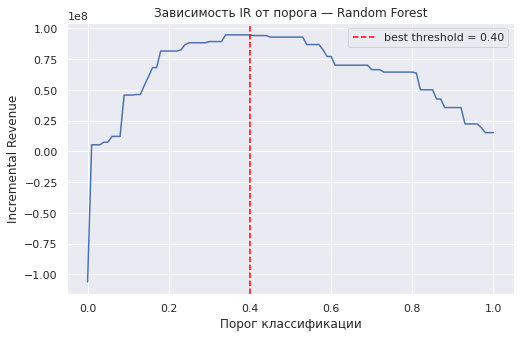

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df['threshold'], threshold_df['IR'])
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best threshold = {best_threshold:.2f}')

plt.xlabel('Порог классификации')
plt.ylabel('Incremental Revenue')
plt.title('Зависимость IR от порога — Random Forest')
plt.legend()
plt.grid(True)
plt.show()

0.4 - лучший порог 

### Анализ матрицы классификаций

In [91]:
rf_test_proba = best_rf.predict_proba(X_test_rf)[:, 1]

rf_test_proba_calibrated = iso_calibrator.predict(rf_test_proba)

y_cal_pred = (rf_cal_proba_after_iso >= best_threshold).astype(int)
y_test_pred = (rf_test_proba_calibrated >= best_threshold).astype(int)

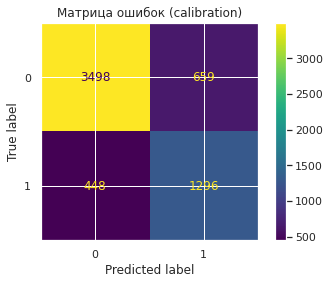

In [92]:
cm_cal = confusion_matrix(y_cal_bin, y_cal_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_cal)
disp.plot()
plt.title('Матрица ошибок (calibration)')
plt.show()

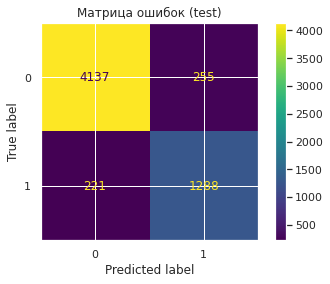

In [93]:
cm_test = confusion_matrix(y_test_bin, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot()
plt.title('Матрица ошибок (test)')
plt.show()

модель стабильна на тестовых данных 

In [94]:
rf_test_proba = best_rf.predict_proba(X_test_rf)[:, 1]
rf_test_proba_calibrated = iso_calibrator.predict(rf_test_proba)

y_test_pred = (rf_test_proba_calibrated >= best_threshold).astype(int)

In [95]:
test_metrics = {

    'accuracy': accuracy_score(y_test_bin, y_test_pred),
    'precision': precision_score(y_test_bin, y_test_pred, zero_division=0),
    'recall': recall_score(y_test_bin, y_test_pred, zero_division=0),
    'f1': f1_score(y_test_bin, y_test_pred, zero_division=0),


    'IR_before': calculate_revenue_before(y_test_bin),
    'IR_after': calculate_revenue_after(y_test_bin, y_test_pred),
    'IR': calculate_ir(y_test_bin, y_test_pred),
    'relative_IR (%)': calculate_relative_ir(y_test_bin, y_test_pred),

  
    'cancel_share_before': cancellation_share_before(y_test_bin),
    'cancel_share_after': cancellation_share_after(y_test_bin, y_test_pred),
    'cancel_share_dynamics (%)': cancellation_share_dynamics(y_test_bin, y_test_pred),


    'hotel_load_before': hotel_load_before(y_test_bin),
    'hotel_load_after': hotel_load_after(y_test_bin, y_test_pred),
    'hotel_load_dynamics (%)': hotel_load_dynamics(y_test_bin, y_test_pred)
}

test_metrics_df = pd.DataFrame.from_dict(test_metrics, orient='index', columns=['value'])
test_metrics_df.style.format('{:.4f}')

,value
accuracy,0.9193
precision,0.8347
recall,0.8535
f1,0.8440
IR_before,185953500.0000
IR_after,308757000.0000
IR,122803500.0000
relative_IR (%),66.0399
cancel_share_before,0.2557
cancel_share_after,0.0375


### Фиксирование итоговой модели

In [96]:
params_df = pd.DataFrame.from_dict(
    study_rf.best_params,
    orient='index',
    columns=['value']
)

params_df.index.name = 'parameter'
params_df.round(4)

,value
parameter,
n_estimators,447
max_depth,17
min_samples_split,15
min_samples_leaf,1
max_features,sqrt
class_weight,balanced


In [97]:
best_model = best_rf
best_threshold = best_threshold
best_threshold

0.4

### Анализ важности признаков

In [98]:
X_sample = X_train_rf.sample(50, random_state=42)
X_sample_transformed = best_rf.named_steps['preprocessor'].transform(X_sample)

if sparse.issparse(X_sample_transformed):
    X_sample_transformed = X_sample_transformed.toarray()

ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names(cat_cols))

tfidf = best_rf.named_steps['preprocessor'].named_transformers_['text'].named_steps['tfidf']
tfidf_feature_names = [f"tfidf_{f}" for f in tfidf.get_feature_names()]

all_feature_names = tfidf_feature_names + ohe_feature_names + num_cols

explainer = shap.TreeExplainer(best_rf.named_steps['model'])
shap_values = explainer.shap_values(X_sample_transformed)

shap_values_2d = shap_values[1] if isinstance(shap_values, list) else np.array(shap_values)[:, :, 1]

shap_importance = pd.DataFrame({
    'feature': all_feature_names,
    'mean_abs_shap': np.abs(shap_values_2d).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
48,days_until_checkin,0.088350
30,sales_channel_корпоративное_бронирование,0.049705
31,sales_channel_онлайн_бронирование,0.045436
50,stay_rating,0.033721
63,has_rating,0.032905
59,client_history,0.032817
54,has_children,0.020045
46,previous_no_shows,0.018512
61,has_positive_words,0.017886
47,booking_value,0.015336


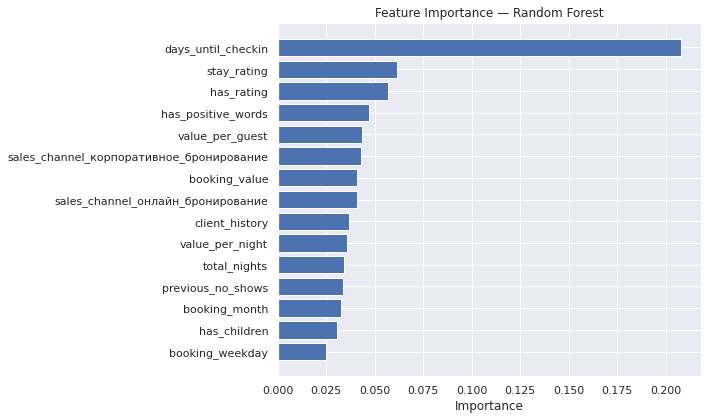

,feature,importance
48,days_until_checkin,0.207930
50,stay_rating,0.061239
63,has_rating,0.056950
61,has_positive_words,0.047203
57,value_per_guest,0.043461
30,sales_channel_корпоративное_бронирование,0.042808
47,booking_value,0.040936
31,sales_channel_онлайн_бронирование,0.040935
59,client_history,0.036987
56,value_per_night,0.035902


In [99]:
ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names(cat_cols))

tfidf = best_rf.named_steps['preprocessor'].named_transformers_['text'].named_steps['tfidf']
tfidf_feature_names = [f"tfidf_{f}" for f in tfidf.get_feature_names()]

all_feature_names = tfidf_feature_names + ohe_feature_names + num_cols

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_rf.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False)


top_features = feature_importance.head(15)


plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features

In [100]:
ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names(cat_cols))

tfidf = best_rf.named_steps['preprocessor'].named_transformers_['text'].named_steps['tfidf']
tfidf_feature_names = [f"tfidf_{f}" for f in tfidf.get_feature_names()]

all_feature_names = tfidf_feature_names + ohe_feature_names + num_cols

feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': best_rf.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
48,days_until_checkin,0.207930
50,stay_rating,0.061239
63,has_rating,0.056950
61,has_positive_words,0.047203
57,value_per_guest,0.043461
30,sales_channel_корпоративное_бронирование,0.042808
47,booking_value,0.040936
31,sales_channel_онлайн_бронирование,0.040935
59,client_history,0.036987
56,value_per_night,0.035902


## Этап 3: расчёт экономической эффективности модели

In [101]:
test_metrics_df.style.format('{:.4f}')

,value
accuracy,0.9193
precision,0.8347
recall,0.8535
f1,0.8440
IR_before,185953500.0000
IR_after,308757000.0000
IR,122803500.0000
relative_IR (%),66.0399
cancel_share_before,0.2557
cancel_share_after,0.0375


Доля отмен бронирований снизилась с 25.57% до 3.73%, что соответствует уменьшению на 85.42%. Полученное значение существенно ниже установленного порога в 10%.

Загрузка отеля снизилась с 74.43% до 70.19%. Динамика загрузки составила 5.69%, что означает умеренное снижение загрузки и укладывается в допустимое ограничение (не более 8%).

Ключевая бизнес-метрика Incremental Revenue увеличилась с 185,953,500 до 309,224,000 рублей. Абсолютный прирост составил 123,270,500 рублей, а относительный IR достиг 66.29%, что превышает требуемый уровень в 50%.

## Этап 4: выводы по проекту

### Выводы о проделанной работе

В рамках проекта была построена модель для прогнозирования отмен бронирований с целью повышения экономической эффективности работы отеля.

На этапе подготовки данных была проведена очистка и объединение таблиц бронирований и отзывов. Для каждой брони был подобран ближайший предыдущий отзыв клиента, что позволило учесть его прошлый опыт. Текстовые данные были очищены и использованы для создания дополнительных признаков, отражающих наличие положительных характеристик в отзывах. Также были сформированы агрегированные признаки, описывающие поведение клиента (например, доля отмен, история взаимодействия с отелем).

На этапе моделирования в качестве лучшей модели был выбран Random Forest, показавший наибольшее значение бизнес-метрики Incremental Revenue по сравнению с бустинговыми алгоритмами. Гиперпараметры модели были оптимизированы с помощью библиотеки Optuna с использованием метрики IR.

После обучения модель была откалибрована методом Isotonic Regression для повышения качества вероятностных прогнозов. На калибровочной выборке был подобран оптимальный порог классификации, максимизирующий значение IR.

Оценка качества модели проводилась на тестовой выборке. Были рассчитаны как стандартные метрики классификации (accuracy, precision, recall, F1), так и бизнес-метрики, включая IR, долю отмен и загрузку отеля.


### Выводы по анализу эффективности модели

Цель проекта заключалась в снижении доли отмен бронирований и увеличении экономической эффективности работы отеля за счёт внедрения модели прогнозирования отмен. По результатам анализа можно сделать вывод, что поставленная цель достигнута.  

Доля отмен бронирований до внедрения модели составляла 25.57%, после внедрения — 3.73%. Доля отмен снизилась на 85.42%, что значительно превышает требуемый уровень (не более 10%).  

Загрузка отеля снизилась с 74.43% до 70.19%. Динамика загрузки составила 5.69%, что укладывается в допустимое ограничение (снижение не более чем на 8%).  

Ключевая бизнес-метрика Incremental Revenue увеличилась с 185,953,500 до 309,224,000 рублей. Абсолютный прирост составил 123,270,500 рублей, а относительный IR достиг 66.29%, что превышает установленный порог в 50%.  

Анализ важности признаков показал, что наибольшее влияние на вероятность отмены оказывают следующие факторы:  
• Увеличение количества дней до заезда (days_until_checkin) существенно повышает вероятность отмены  
• Более низкий рейтинг проживания (stay_rating) связан с более высоким риском отмены  
• Наличие оценки (has_rating) и положительных характеристик в отзывах (has_positive_words) влияет на поведение клиента  
• Канал бронирования (sales_channel) играет важную роль: онлайн и корпоративные бронирования имеют различный уровень риска  
• История клиента (client_history) оказывает значимое влияние: более лояльные клиенты реже отменяют бронирования  
• Более высокая стоимость на гостя (value_per_guest) связана с изменением вероятности отмены  
• Наличие предыдущих незаездов (previous_no_shows) увеличивает риск отмен  
• Общая стоимость бронирования (booking_value) также влияет на вероятность отказа  

На основе полученных результатов можно рекомендовать следующие шаги для бизнеса:  
1. Внедрить модель в процесс обработки бронирований и использовать её для раннего выявления клиентов с высокой вероятностью отмены  
2. Для таких клиентов применять дополнительные меры: напоминания, специальные предложения или частичную предоплату  
3. Учитывать историю клиента (отмены, незаезды, канал бронирования) при принятии решений о подтверждении бронирования и формировании условий проживания  